# 🔥 Validación Cruzada, Overfitting y Underfitting
## Aplicado al dataset de focos de calor NASA FIRMS (Bolivia)

Este notebook adapta 4 ejercicios de clase al dataset real del proyecto (no datos sintéticos de `iris` ni ruido artificial):

1. **Validación cruzada K-Fold** con Árbol de Decisión (clasificación `daynight_num`).
2. **Comparación de estrategias de validación cruzada**: K-Fold vs Stratified K-Fold vs Leave-One-Out.
3. **Overfitting** con regresión polinomial (relación real `brightness` → `frp_log`).
4. **Underfitting** con regresión lineal vs polinomial (mismos datos reales).

> **Sobre el uso de todos los datos:** los modelos se entrenan con el 100% del dataset de entrenamiento disponible en cada sección. La única excepción es puramente **visual**: graficar 500,000+ puntos en un scatter o dibujar el detalle de Leave-One-Out con 500,000 folds es ilegible e inviable, así que en esos casos puntuales se grafica solo una muestra aleatoria — pero el **entrenamiento y las métricas siempre usan todos los datos** (excepto Leave-One-Out, que se explica por qué es computacionalmente inviable a esta escala).


## 0. Librerías y carga de datos

In [7]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option("display.max_columns", None)
sns.set_theme(style="whitegrid")

from sklearn.model_selection import (
    train_test_split, KFold, StratifiedKFold, LeaveOneOut, cross_val_score
)
from sklearn.tree import DecisionTreeClassifier
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures, StandardScaler
from sklearn.metrics import accuracy_score, mean_squared_error

RANDOM_STATE = 42


In [8]:
RUTA_CSV = "dataset_incendios_listo_modelos.csv"  # <-- CAMBIA ESTO por la ruta real de tu dataset

df = pd.read_csv(RUTA_CSV)
print("Filas totales:", len(df))

cols_necesarias = ['brightness', 'bright_t31', 'scan', 'track', 'confidence_num',
                    'frp_log', 'daynight_num']
df = df.dropna(subset=cols_necesarias).copy()
print("Filas tras limpieza (se usan TODAS en este notebook):", len(df))


Filas totales: 671786
Filas tras limpieza (se usan TODAS en este notebook): 671786


---
## PARTE 1 — Validación Cruzada K-Fold con Árbol de Decisión

Se evalúa un `DecisionTreeClassifier` prediciendo `daynight_num`, usando **el 100% de los datos limpios** repartidos en 5 particiones (folds).

In [9]:
features_clf = ['brightness', 'bright_t31', 'scan', 'track', 'confidence_num']
X = df[features_clf].values
y = df['daynight_num'].values

print("X:", X.shape, " y:", y.shape)
print("Balance de clases:", np.bincount(y) / len(y))


X: (671786, 5)  y: (671786,)
Balance de clases: [0.411512 0.588488]


In [10]:
# --- K-Fold con 5 particiones y mezcla aleatoria, sobre TODOS los datos ---
kf = KFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
modelo_arbol = DecisionTreeClassifier(max_depth=10, random_state=RANDOM_STATE)

scores_kf = cross_val_score(modelo_arbol, X, y, cv=kf, n_jobs=-1)

print("Accuracy en cada fold:", np.round(scores_kf, 4))
print("Accuracy promedio:", round(scores_kf.mean(), 4))
print("Desviación estándar:", round(scores_kf.std(), 4))


Accuracy en cada fold: [0.9121 0.9124 0.9116 0.9112 0.9114]
Accuracy promedio: 0.9117
Desviación estándar: 0.0004


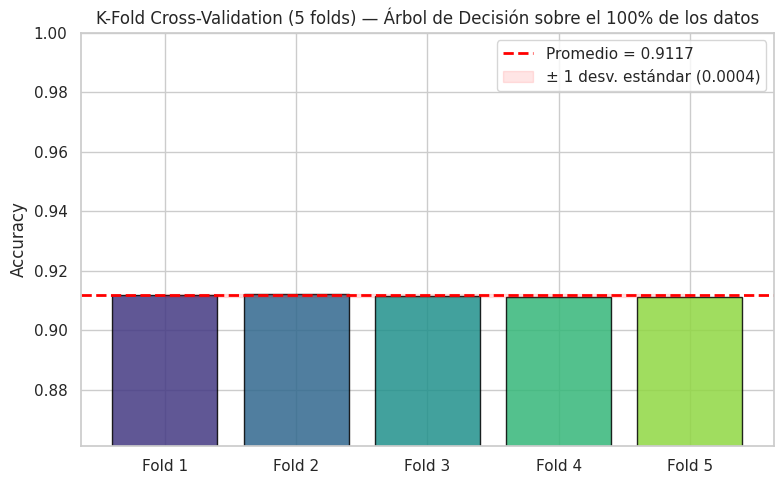

In [11]:
# --- Gráfico profesional: accuracy por fold + promedio +/- desviación estándar ---
fig, ax = plt.subplots(figsize=(8, 5))
folds = [f"Fold {i+1}" for i in range(len(scores_kf))]
colors = sns.color_palette("viridis", len(scores_kf))

ax.bar(folds, scores_kf, color=colors, edgecolor="black", alpha=0.85)
ax.axhline(scores_kf.mean(), color="red", linestyle="--", linewidth=2,
           label=f"Promedio = {scores_kf.mean():.4f}")
ax.fill_between(folds, scores_kf.mean() - scores_kf.std(), scores_kf.mean() + scores_kf.std(),
                 color="red", alpha=0.1, label=f"± 1 desv. estándar ({scores_kf.std():.4f})")

ax.set_ylim(max(0, scores_kf.min() - 0.05), 1.0)
ax.set_ylabel("Accuracy")
ax.set_title("K-Fold Cross-Validation (5 folds) — Árbol de Decisión sobre el 100% de los datos")
ax.legend()
plt.tight_layout()
plt.show()


---
## PARTE 2 — Comparación de estrategias: K-Fold vs Stratified K-Fold vs Leave-One-Out

### 2.1 Visualización de los splits (ilustrativa)

Graficar la asignación train/validación de 500,000+ filas es ilegible. Esta visualización usa una **muestra pequeña solo para fines ilustrativos** (para que se vea el patrón de particiones); las métricas de las secciones siguientes sí usan el dataset completo (excepto Leave-One-Out, ver 2.4).

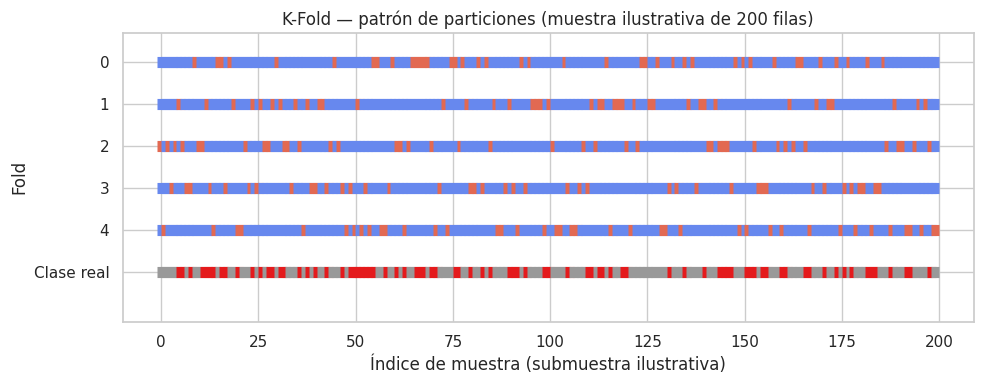

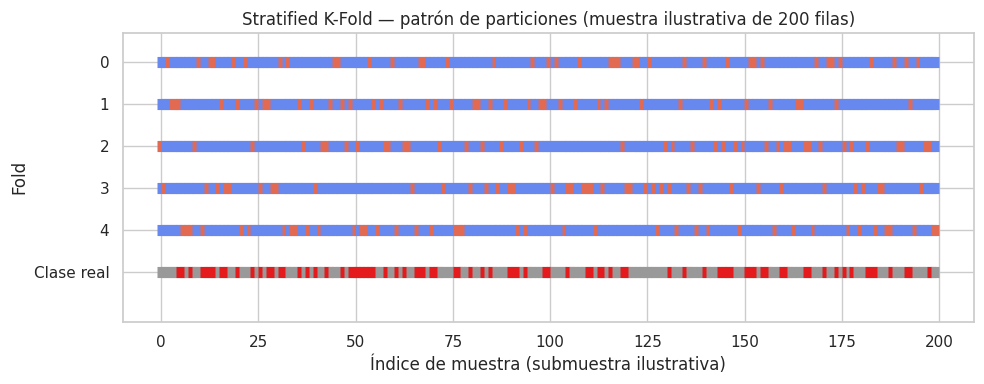

In [14]:
def plot_cv_indices(cv, X_vis, y_vis, n_splits, title):
    fig, ax = plt.subplots(figsize=(10, 4))
    cmap_cv = plt.cm.coolwarm
    for ii, (tr, tt) in enumerate(cv.split(X=X_vis, y=y_vis)):
        indices = np.array([np.nan] * len(X_vis))
        indices[tt] = 1
        indices[tr] = 0
        ax.scatter(range(len(indices)), [ii + 0.5] * len(indices),
                   c=indices, marker="_", lw=8, cmap=cmap_cv, vmin=-0.2, vmax=1.2)
    ax.scatter(range(len(X_vis)), [n_splits + 0.5] * len(X_vis), c=y_vis, marker="_", lw=8, cmap="Set1")
    ax.set(
        yticks=np.arange(n_splits + 1) + 0.5,
        yticklabels=list(range(n_splits)) + ["Clase real"],
        xlabel="Índice de muestra (submuestra ilustrativa)",
        ylabel="Fold",
        title=title,
        ylim=[n_splits + 1.7, -0.2],
    )
    plt.tight_layout()
    plt.show()

# Submuestra estratificada solo para la visualización (200 filas)
idx_vis, _ = train_test_split(np.arange(len(X)), train_size=200, random_state=RANDOM_STATE, stratify=y)
X_vis, y_vis = X[idx_vis], y[idx_vis]

plot_cv_indices(KFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE), X_vis, y_vis, 5,
                "K-Fold — patrón de particiones (muestra ilustrativa de 200 filas)")
plot_cv_indices(StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE), X_vis, y_vis, 5,
                "Stratified K-Fold — patrón de particiones (muestra ilustrativa de 200 filas)")

### 2.2 K-Fold vs Stratified K-Fold — accuracy sobre el 100% de los datos

In [15]:
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

scores_skf = cross_val_score(modelo_arbol, X, y, cv=skf, n_jobs=-1)

print("Stratified K-Fold accuracies:", np.round(scores_skf, 4))
print("Stratified K-Fold accuracy promedio:", round(scores_skf.mean(), 4))


Stratified K-Fold accuracies: [0.911  0.9115 0.9105 0.9125 0.9109]
Stratified K-Fold accuracy promedio: 0.9113


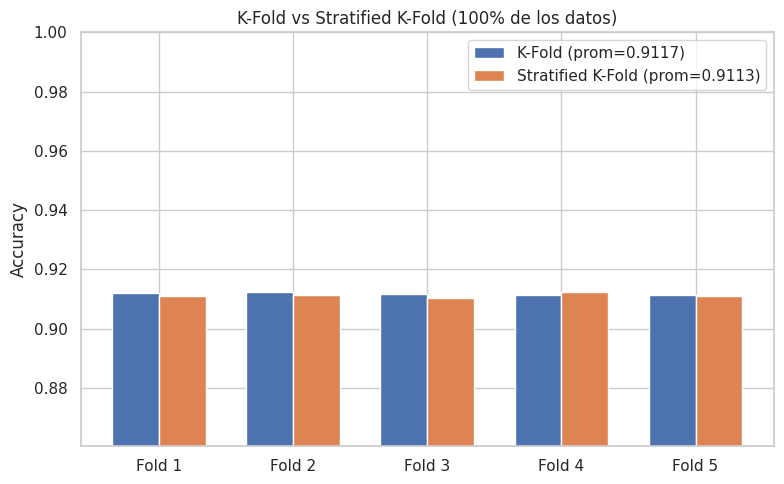

In [16]:
fig, ax = plt.subplots(figsize=(8, 5))
x_pos = np.arange(5)
width = 0.35

ax.bar(x_pos - width/2, scores_kf, width, label=f"K-Fold (prom={scores_kf.mean():.4f})", color="#4C72B0")
ax.bar(x_pos + width/2, scores_skf, width, label=f"Stratified K-Fold (prom={scores_skf.mean():.4f})", color="#DD8452")

ax.set_xticks(x_pos)
ax.set_xticklabels([f"Fold {i+1}" for i in range(5)])
ax.set_ylabel("Accuracy")
ax.set_ylim(max(0, min(scores_kf.min(), scores_skf.min()) - 0.05), 1.0)
ax.set_title("K-Fold vs Stratified K-Fold (100% de los datos)")
ax.legend()
plt.tight_layout()
plt.show()


### 2.3 Leave-One-Out — por qué NO se aplica a los 187,000+ / 670,000+ datos completos

Leave-One-Out entrena **un modelo por cada fila del dataset** (deja 1 dato fuera, entrena con el resto, repite para cada fila). Con 500,000+ filas eso implicaría **500,000+ entrenamientos completos de un árbol de decisión** — en la práctica, horas o días de cómputo solo para esta validación. Por eso, **en la industria LOO prácticamente nunca se usa con datasets grandes**; se reserva para datasets pequeños (cientos de filas).

Para ilustrar el concepto (no para evaluar el modelo final), se aplica aquí sobre una muestra pequeña y estratificada de 300 filas.

In [17]:
idx_loo, _ = train_test_split(np.arange(len(X)), train_size=300, random_state=RANDOM_STATE, stratify=y)
X_loo, y_loo = X[idx_loo], y[idx_loo]

loo = LeaveOneOut()
scores_loo = cross_val_score(modelo_arbol, X_loo, y_loo, cv=loo, n_jobs=-1)

print(f"Leave-One-Out sobre {len(X_loo)} filas (muestra, NO el dataset completo)")
print("Cantidad de folds (= cantidad de filas):", len(scores_loo))
print("Accuracy promedio LOO:", round(scores_loo.mean(), 4))


Leave-One-Out sobre 300 filas (muestra, NO el dataset completo)
Cantidad de folds (= cantidad de filas): 300
Accuracy promedio LOO: 0.8767


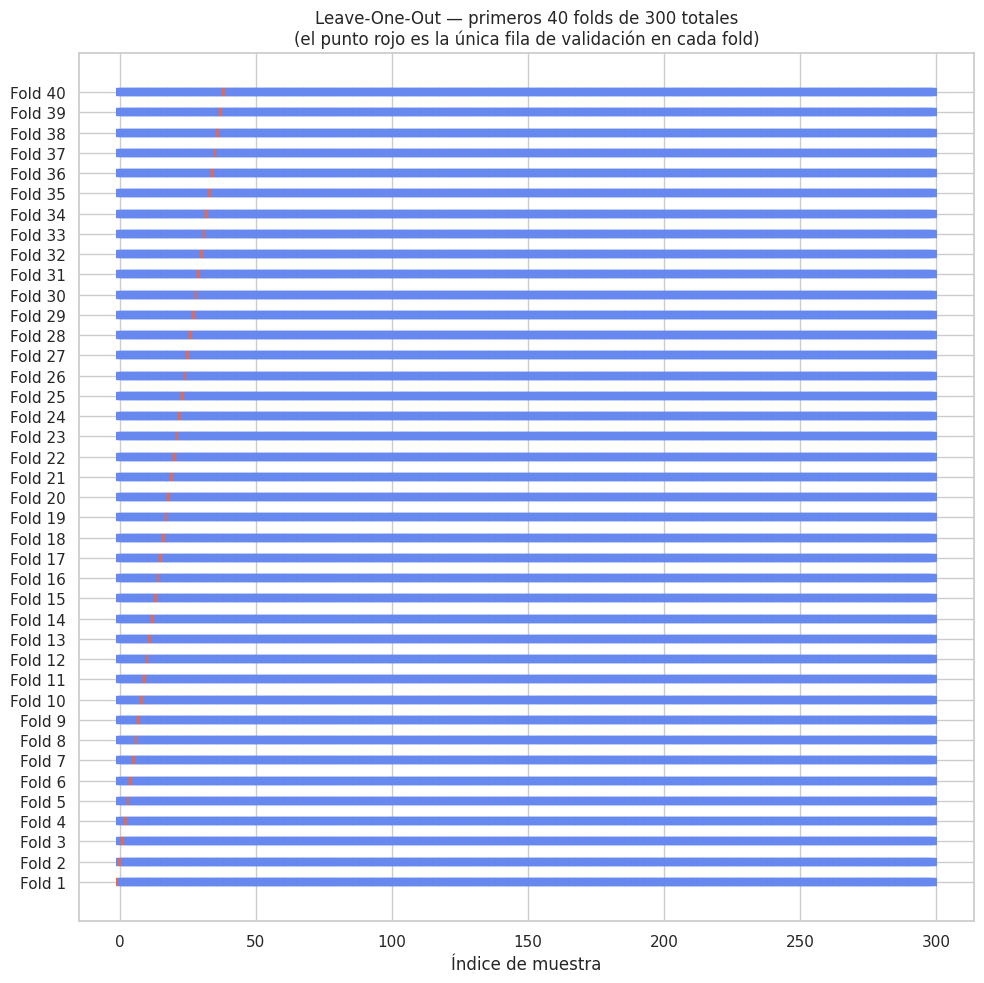

In [18]:
def plot_loo_splits(n_muestras, max_folds_mostrados=40):
    n_mostrar = min(n_muestras, max_folds_mostrados)
    fig, ax = plt.subplots(figsize=(10, n_mostrar * 0.25))
    for i in range(n_mostrar):
        estado = np.zeros(n_muestras)
        estado[i] = 1  # la fila i es la validación en el fold i
        ax.scatter(range(n_muestras), [i] * n_muestras, c=estado, cmap="coolwarm",
                   marker="_", lw=6, vmin=-0.2, vmax=1.2)
    ax.set_yticks(range(n_mostrar))
    ax.set_yticklabels([f"Fold {i+1}" for i in range(n_mostrar)])
    ax.set_xlabel("Índice de muestra")
    ax.set_title(f"Leave-One-Out — primeros {n_mostrar} folds de {n_muestras} totales\n"
                 "(el punto rojo es la única fila de validación en cada fold)")
    plt.tight_layout()
    plt.show()

plot_loo_splits(len(X_loo))


### 2.4 Comparación final de las 3 estrategias

In [19]:
comparacion_cv = pd.DataFrame({
    "Estrategia": ["K-Fold (100% datos)", "Stratified K-Fold (100% datos)", "Leave-One-Out (muestra 300 filas)"],
    "Accuracy promedio": [scores_kf.mean(), scores_skf.mean(), scores_loo.mean()],
    "Desv. estándar": [scores_kf.std(), scores_skf.std(), scores_loo.std()],
    "N° de folds": [5, 5, len(X_loo)],
})
comparacion_cv


,Estrategia,Accuracy promedio,Desv. estándar,N° de folds
0,K-Fold (100% datos),0.911746,0.000433,5
1,Stratified K-Fold (100% datos),0.911298,0.000689,5
2,Leave-One-Out (muestra 300 filas),0.876667,0.328819,300


---
## PARTE 3 — Overfitting con regresión polinomial (datos reales: `brightness` → `frp_log`)

En vez de datos sintéticos, se usa la relación real entre `brightness` y `frp_log` (ya vimos en el análisis de regresión que esta relación es no lineal). Se ajustan polinomios de distinto grado sobre **el 100% del set de entrenamiento**; solo el *scatter* de fondo grafica una muestra aleatoria para que se vea legible — la curva y el MSE se calculan con todos los datos.

In [20]:
# Variable única, estandarizada para estabilidad numérica en polinomios de grado alto
X_over = df[['brightness']].values
y_over = df['frp_log'].values

Xo_train, Xo_test, yo_train, yo_test = train_test_split(
    X_over, y_over, test_size=0.2, random_state=RANDOM_STATE
)

scaler_over = StandardScaler()
Xo_train_s = scaler_over.fit_transform(Xo_train)
Xo_test_s = scaler_over.transform(Xo_test)

X_plot_over = np.linspace(Xo_train_s.min(), Xo_train_s.max(), 200).reshape(-1, 1)

print("Entrenamiento (100% usado para ajustar el polinomio):", Xo_train_s.shape)


Entrenamiento (100% usado para ajustar el polinomio): (537428, 1)


In [21]:
def plot_poly_fit(degree, sample_for_plot=4000):
    poly = PolynomialFeatures(degree)
    Xo_train_poly = poly.fit_transform(Xo_train_s)
    Xo_test_poly = poly.transform(Xo_test_s)

    modelo = LinearRegression().fit(Xo_train_poly, yo_train)  # ajustado con el 100% del train

    mse_train = mean_squared_error(yo_train, modelo.predict(Xo_train_poly))
    mse_test = mean_squared_error(yo_test, modelo.predict(Xo_test_poly))

    y_plot = modelo.predict(poly.transform(X_plot_over))

    # Solo el scatter de fondo usa una muestra aleatoria (fines de legibilidad)
    idx_plot = np.random.RandomState(RANDOM_STATE).choice(
        len(Xo_train_s), size=min(sample_for_plot, len(Xo_train_s)), replace=False
    )

    plt.figure(figsize=(8, 5))
    plt.scatter(Xo_train_s[idx_plot], yo_train[idx_plot], s=6, alpha=0.25,
                label=f"Datos de entrenamiento (muestra de {sample_for_plot} para graficar)")
    plt.plot(X_plot_over, y_plot, color="red", linewidth=2.5, label=f"Polinomio grado {degree}")
    plt.xlabel("brightness (estandarizado)")
    plt.ylabel("frp_log")
    plt.title(f"Grado {degree} — MSE train={mse_train:.4f} | MSE test={mse_test:.4f}\n"
              f"(ajustado con las {len(Xo_train_s)} filas de entrenamiento)")
    plt.legend()
    plt.tight_layout()
    plt.show()

    return mse_train, mse_test


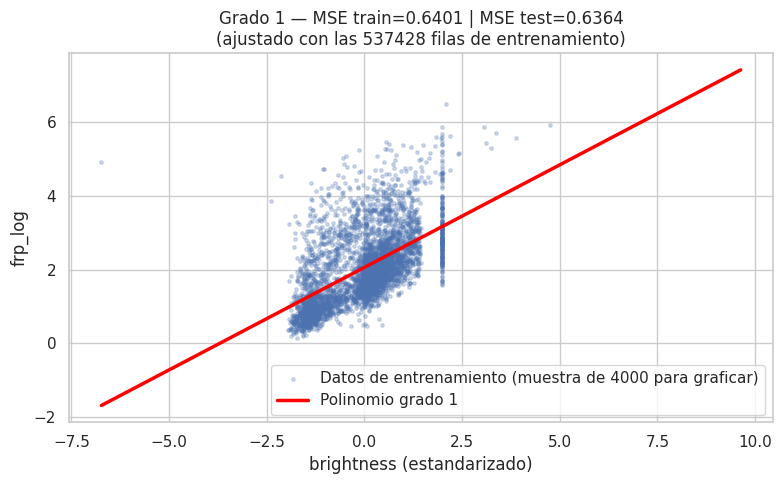

In [22]:
# Subajuste: el polinomio de grado 1 no captura la curvatura real de la relación
mse_train_1, mse_test_1 = plot_poly_fit(1)


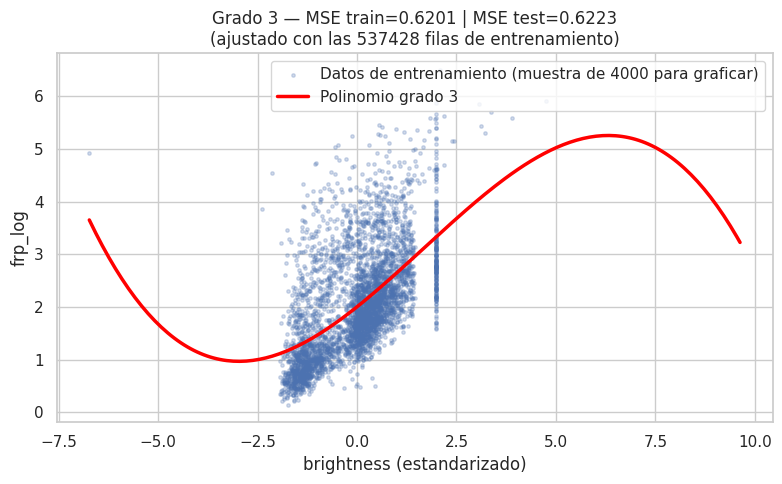

In [23]:
# Ajuste razonable: grado 2-3 captura la tendencia sin perseguir el ruido
mse_train_3, mse_test_3 = plot_poly_fit(3)


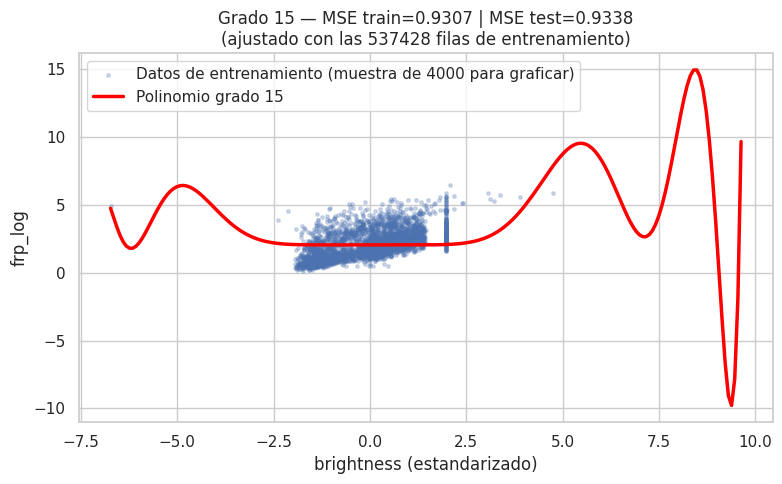

In [24]:
# Sobreajuste: grado alto memoriza el ruido de entrenamiento
mse_train_15, mse_test_15 = plot_poly_fit(15)


### 3.1 Curva de complejidad (Train MSE vs Test MSE) — la evidencia numérica del overfitting

Este es el gráfico más importante de la sección: si solo miras el MSE de entrenamiento (como en el ejemplo original), **nunca vas a detectar el overfitting** — el MSE de entrenamiento baja (o se mantiene) con cada grado adicional. El overfitting se detecta comparando train vs test: cuando el error de test empieza a subir mientras el de entrenamiento sigue bajando, ahí está el punto en que el modelo empieza a memorizar en vez de generalizar.

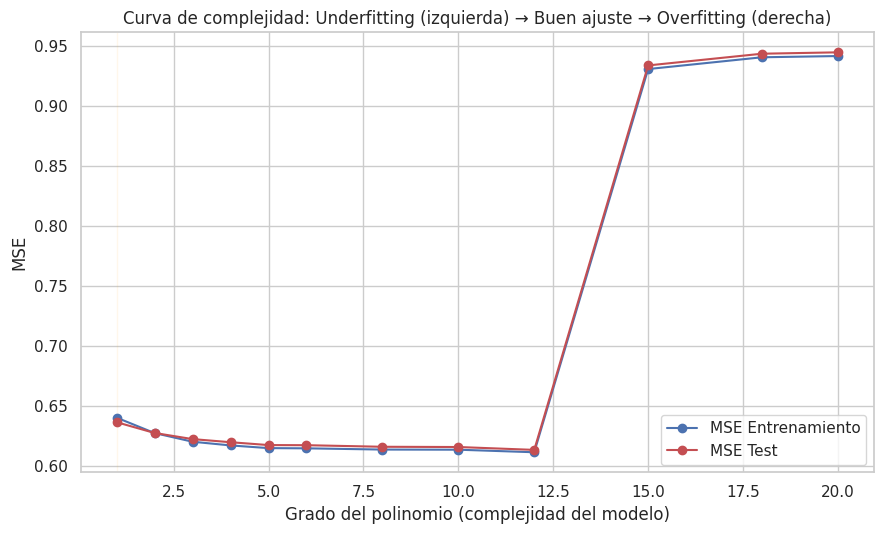

,Grado,MSE Train,MSE Test
0,1,0.640138,0.636353
1,2,0.627296,0.627372
2,3,0.620083,0.622280
3,4,0.617011,0.619678
4,5,0.614765,0.617303
5,6,0.614584,0.617197
6,8,0.613559,0.615881
7,10,0.613446,0.615681
8,12,0.611317,0.613287
9,15,0.930739,0.933762


In [25]:
grados = [1, 2, 3, 4, 5, 6, 8, 10, 12, 15, 18, 20]
mse_train_list, mse_test_list = [], []

for g in grados:
    poly = PolynomialFeatures(g)
    Xo_train_poly = poly.fit_transform(Xo_train_s)
    Xo_test_poly = poly.transform(Xo_test_s)
    modelo = LinearRegression().fit(Xo_train_poly, yo_train)
    mse_train_list.append(mean_squared_error(yo_train, modelo.predict(Xo_train_poly)))
    mse_test_list.append(mean_squared_error(yo_test, modelo.predict(Xo_test_poly)))

plt.figure(figsize=(9, 5.5))
plt.plot(grados, mse_train_list, "o-", color="#4C72B0", label="MSE Entrenamiento")
plt.plot(grados, mse_test_list, "o-", color="#C44E52", label="MSE Test")
plt.axvspan(1, 1, color="orange", alpha=0.08)
plt.xlabel("Grado del polinomio (complejidad del modelo)")
plt.ylabel("MSE")
plt.title("Curva de complejidad: Underfitting (izquierda) → Buen ajuste → Overfitting (derecha)")
plt.legend()
plt.tight_layout()
plt.show()

pd.DataFrame({"Grado": grados, "MSE Train": mse_train_list, "MSE Test": mse_test_list})


---
## PARTE 4 — Underfitting: Regresión Lineal vs Polinomial (datos reales)

Se compara directamente un modelo lineal (grado 1) contra uno polinomial de grado moderado, ambos ajustados con el **100% de los datos de entrenamiento**, para mostrar cómo el modelo lineal subestima la curvatura real de la relación `brightness` → `frp_log`.

In [26]:
# Modelo lineal (grado 1) — candidato a underfitting
modelo_lineal = LinearRegression().fit(Xo_train_s, yo_train)
mse_train_lineal = mean_squared_error(yo_train, modelo_lineal.predict(Xo_train_s))
mse_test_lineal = mean_squared_error(yo_test, modelo_lineal.predict(Xo_test_s))

# Modelo polinomial grado 3 — mejor ajuste
poly3 = PolynomialFeatures(degree=3)
Xo_train_poly3 = poly3.fit_transform(Xo_train_s)
Xo_test_poly3 = poly3.transform(Xo_test_s)
modelo_poly3 = LinearRegression().fit(Xo_train_poly3, yo_train)
mse_train_poly3 = mean_squared_error(yo_train, modelo_poly3.predict(Xo_train_poly3))
mse_test_poly3 = mean_squared_error(yo_test, modelo_poly3.predict(Xo_test_poly3))

print(f"Lineal        -> MSE train={mse_train_lineal:.4f}  MSE test={mse_test_lineal:.4f}")
print(f"Polinomio g3  -> MSE train={mse_train_poly3:.4f}  MSE test={mse_test_poly3:.4f}")


Lineal        -> MSE train=0.6401  MSE test=0.6364
Polinomio g3  -> MSE train=0.6201  MSE test=0.6223


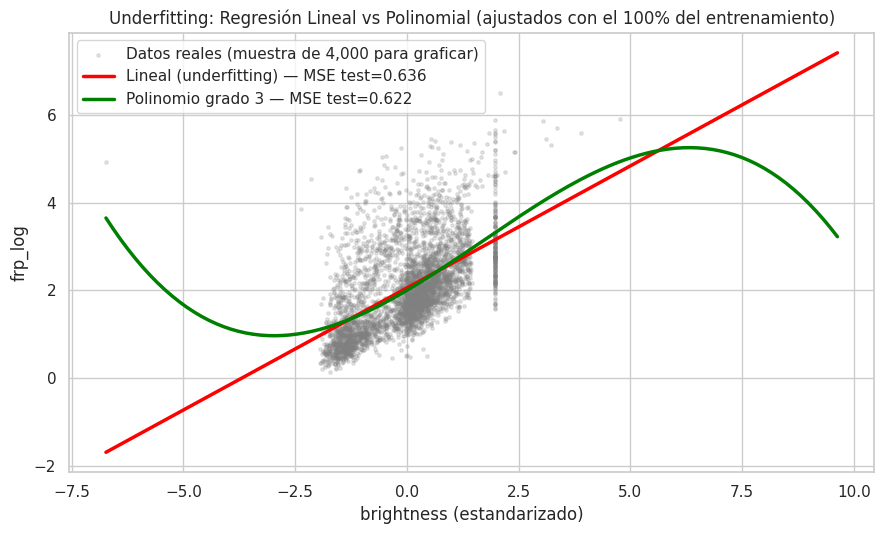

In [27]:
idx_plot = np.random.RandomState(RANDOM_STATE).choice(len(Xo_train_s), size=4000, replace=False)
y_plot_lineal = modelo_lineal.predict(X_plot_over)
y_plot_poly3 = modelo_poly3.predict(poly3.transform(X_plot_over))

plt.figure(figsize=(9, 5.5))
plt.scatter(Xo_train_s[idx_plot], yo_train[idx_plot], s=6, alpha=0.2, color="gray",
            label="Datos reales (muestra de 4,000 para graficar)")
plt.plot(X_plot_over, y_plot_lineal, color="red", linewidth=2.5,
         label=f"Lineal (underfitting) — MSE test={mse_test_lineal:.3f}")
plt.plot(X_plot_over, y_plot_poly3, color="green", linewidth=2.5,
         label=f"Polinomio grado 3 — MSE test={mse_test_poly3:.3f}")
plt.xlabel("brightness (estandarizado)")
plt.ylabel("frp_log")
plt.title("Underfitting: Regresión Lineal vs Polinomial (ajustados con el 100% del entrenamiento)")
plt.legend()
plt.tight_layout()
plt.show()


### Conclusión (plantilla a completar)

- ¿Con cuántos folds/qué estrategia (K-Fold vs Stratified) obtuviste métricas más estables (menor desviación estándar) para el árbol de decisión?
- ¿Por qué Leave-One-Out no es viable con el dataset completo, y qué tan distinta fue su accuracy respecto a K-Fold en la muestra de 300 filas?
- Según la curva de complejidad (Parte 3.1), ¿a partir de qué grado el MSE de test empieza a subir mientras el de entrenamiento sigue bajando? Ese es tu punto de overfitting.
- ¿Qué tan grande fue la brecha entre MSE train y MSE test para el modelo lineal (Parte 4)? Esa brecha pequeña pero con MSE alto en ambos es la firma típica de underfitting (a diferencia del overfitting, donde la brecha es grande).
